# [1교시]

In [1]:
# 불린형 0과 1
samples = [True, False]
sum(samples)

# ""과 " "의 차이: 0과 1

1

In [3]:
samples = [True, False, False]
any(samples) # 한 개라도 True면 전체가 True
all(samples) # 전체가 True면 결과가 True

#df[df.isnull().any(axis=1)] #axis = 1은 진행방향으로 해석됨

False

In [4]:
# 강사님과 진행하는 예제풀이 1
# 범주형 데이터 같은 경우에는 모듈을 사용한다.
# .mode를 통해 최빈값을 구할 수 있다.

samples = [True, False, False]
all(samples)
import numpy as np
import pandas as pd
samples = np.array(['사과', '바나나', '딸기', '사과', '오렌지', '바나나']) 
df = pd.DataFrame(samples, columns=['과일'])
df['과일'].mode()

0    바나나
1     사과
Name: 과일, dtype: object

In [5]:
# ffill과 bfill 비교
# ffill은 forward fill, bfill은 backfill
# 각각 앞과 뒤를 채우는 함수로 시계열에 유용하게 쓰임

# 보간법(Interpolation)
- 결측치 주변의 값들을 이용해서 수학적으로 추정하여 채움

- 추론: 오차가 최소한이 되도록 추론하여 값을 계산해서 넣어줌

- 선형 보간: 직선, 빠르고 간단하며 값의 변화가 완만할 때 적합
- 다항식 보간: 곡선, 고차원(컬럼 개수가 많을 때)일수록 오버피팅 위험
- 시간 기반 보간 : 시간을 나타낼 때

# [2교시]

In [6]:
# 강사님과 진행하는 예제풀이 2
# 결측치 탐지
import pandas as pd
import numpy as np


df = pd.read_csv(r'data\messy_data.csv')
df

,id,name,age,salary,score,department
0,1,user_1,56.0,59545.0,17.50,마케팅
1,2,user_2,46.0,36399.0,98.22,영업
2,3,user_3,32.0,57141.0,51.66,개발
3,4,user_4,60.0,69555.0,26.08,재무
4,5,user_5,25.0,53174.0,99.63,개발
...,...,...,...,...,...,...
107,81,user_81,38.0,50421.0,NaN,영업
108,11,user_11,28.0,64250.0,70.04,인사
109,1,user_1,56.0,59545.0,17.50,마케팅
110,19,user_19,41.0,38304.0,66.90,인사


In [ ]:
print(f'원본 데이터 shape : {df.shape}')
print(f'결측치 개수 : {df.isnull().sum().sum()}')
print(f'결측치 비율 : {df.isnull().mean().round(2)}')
print(f'결측치가 포함된 행의 개수 : {df.isnull().any(axis=1).sum()}')

In [ ]:
df.tail().isnull().astype(int)

In [ ]:
# 결측치 삭제
# 결측치가 있는 행만 출력
# .any()는 컬럼에서 결측치 하나라도 있는 것들 출력
df[df.isna().any(axis=1)]
# 결측치가 하나라도 있는 행을 삭제
df_drop_any = df.dropna(how='any')
# len(df_drop_any), len(df)
# 모든 값이 NaN인 행만 삭제
df_drop_all = df.dropna(how='all')
len(df_drop_all) 
# 특정컬럼기준 삭제
df.dropna(subset=['age', 'salary'])
# thresh - 최소 N개 유효값이 있어야 보존(삭제의 기준이 아닌 살리는 기준으로 봐야함)
# 임계치 이상의 데이터만 남겨놓는다.(NaN의 개수가 아닌 정상데이터의 개수)
df_drop_thresh = df.dropna(thresh=4)
df_drop_thresh[df_drop_thresh.isna().any(axis=1)]

In [ ]:
# 결측치 대치
# 고정값으로 대치
df_fill_zero = df.copy()
# df_fill_zero['score']
df_fill_zero.isna().any()
# 결측치만 있는 columns을 출력
temp = df_fill_zero.isna().any()
print(temp[temp.values].index)
# df_fill_zero['score'].fillna(0)
df_fill_zero['score'].fillna(df_fill_zero['score'].median())
dept_mode = df_fill_zero['department'].mode()[0]
df_fill_zero['age'].bfill()

In [ ]:
import pandas as pd
import numpy as np
pd.read_csv(r'data\messy_data.csv')
df.head(2)
# 보간
# 선형 보간
# df['score'].linear
# 다항식 보간
df['score'].interpolate(method='polynomial', order=3)

In [ ]:
import pandas as pd
import numpy as np
from glob import glob
df = pd.read_csv(glob('*.csv')[2],low_memory=False)
df

In [ ]:
# df.isnull().mean()
len(df.columns)

# [3교시]
## 이상치
- 데이터 분포에서 극단적으로 벗어난 값

## IQR(사분위 범위) 방식

- Q1 = 25번째 백분위수
- Q3 = 75번째 백분위수
- IQR = Q3 - Q1

- 하한(Lower Bound) = Q1 - 1.5 × IQR
- 상한(Upper Bound) = Q3 + 1.5 × IQR

- → 하한 미만 또는 상한 초과 = 이상치

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask = (data[column] < lower) | (data[column] > upper)
    return outlier_mask, lower, upper

# 이상치 제거
mask, lower, upper = detect_outliers_iqr(df, 'salary')
df_clean = df[~mask]
# 이상치를 제거하여, 이상치가 아닌 데이터들만 가져온다

In [ ]:
# 강사님과 함께하는 예제 실습!
# 이상치 탐지
# %pwd
import pandas as pd
import numpy as np
df = pd.read_csv(r'data\messy_data.csv')
na_cols = df.isna().any()[df.isna().any().values].index
# 이상치 탐지를 위해서 결측치를 중앙값으로 대처
for col in na_cols:
    df[col].fillna(df[col].median)

In [ ]:
df.shape

In [ ]:
df.describe()


In [ ]:
df[na_cols].describe()

### 이상치 확인
- 평균으로부터 min, max가 극단적으로 벗어나있으면 이상치인지 의심을 해보면 된다.

In [ ]:
# 강사님과 함께하는 예제 실습!
# 이상치 탐지
# %pwd
import pandas as pd
import numpy as np
df = pd.read_csv(r'data\messy_data.csv')
numeric_cols = df.describe().columns
# na_cols = df.isna().any()[df.isna().any().values].index

# # 이상치 탐지를 위해서 결측치를 중앙값으로 대처
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# [4교시]

In [ ]:
# 불린 인덱스 == mask

In [ ]:
# IQR
# 4분위 함수

def detect_outlier_iqr(data, column):
    Q1 = data[column].quantile(0.25)*1.5
    Q3 = data[column].quantile(0.75)*1.5
    IQR = Q3 - Q1
    lower = Q1 - IQR
    upper = Q3 + IQR
    outlier_mask = (data[column] > upper) | (data[column] < lower)
    return outlier_mask, lower, upper, Q1, Q3, IQR

df

In [ ]:
# def함수를 사용해서 이상치 여부 확인
for idx, row in df.iterrows():
    print(row['name'])

In [ ]:
for colname in df:
    print(colname)
    (detect_outlier_iqr(df, colname))
    # name 컬럼은 문자라 "-" 연산자가 성립이 되지 않기 때문에 에러가 생긴다.
    # 수치형 데이터 컬럼만 사용해야 한다.

In [ ]:
# # 수치형 데이터 컬람 찾아내기

# numeric_cols = df.describe().columns[1:]

# for colname in numeric_cols:
#     outlier_mask, lower, upper, Q1, Q3, IQR = detect_outlier_iqr(df, colname)
#     print(f'컬럼명 : {colname}')
#     print(f'이상치 개수 : {outlier_mask.sum()}')
#     print('-'*50)
#     ~outlier_mask



In [ ]:
numeric_cols = df.describe().columns[1:]

iqr_df = df.copy()
total_removed_counts = 0
for colname in numeric_cols:
    outlier_mask, lower, upper, Q1, Q3, IQR = detect_outlier_iqr(iqr_df, colname)
    print(f'컬럼명 : {colname}')
    print(f'이상치 개수 : {outlier_mask.sum()}')
    print('-'*50)
    before = len(iqr_df)
    iqr_df = iqr_df[~outlier_mask]
    removed = before - len(iqr_df)
    total_removed_counts += removed

print(f'IQR 제거 후 shape {iqr_df.shape}')
print(f'총 제거수 : {total_removed_counts}')

# [5교시]

In [ ]:
# z-score 방식
# 이상치가 극단적으로 많거나 적으면 불안하다

# 1, 2, 3, 4, 5일때는 중위수가 3이지만
# 1, 2, 3, 4, 5, 6일 때는 중위수는 3.5의 값을 가져온다

from scipy import stats
df['age'].isna().sum()

In [ ]:
for i in df['age']:
    print(type(i))

In [ ]:
# 데이터가 정규분포를 따른다고 가정
from scipy import stats
# (각 요소 - 평균) / 표준편차 
stats.zscore(df['age'] > 3)
df['age'].isna().sum()

In [ ]:
# zscore 확인

m = df['age'].mean()
s = df['age'].std()
(df['age'][0] - m) / s

In [ ]:
# 데이터가 정규분포를 따른다고 가정
from scipy import stats
# (각 요소 - 평균) / 표준편차 
def detect_outlier_zscore(data, column, threshold=3):
    np.abs(stats.zscore(data[colname].dropna()))

In [ ]:
# -값의 절대값을 측정할 때 제곱을 하고, 루트를 씌워서 -를 없앤다.
np.abs([-1,-2,3])

In [ ]:
# 데이터가 정규분포를 따른다고 가정
from scipy import stats
# (각 요소 - 평균) / 표준편차 
def detect_outlier_zscore(data, colname, threshold=3):
    z_score = np.abs(stats.zscore(data[colname].dropna()))
    return ~(z_score > threshold)

In [ ]:
df[~detect_outlier_zscore(df,'age')]

In [ ]:
for col in numeric_cols:
    before = len(df)
    zscore_index = detect_outlier_zscore(df, col)
    df = df[zscore_index]
    removed = before - len(df)
    print(col, removed)

In [ ]:
# 이상치 탐색(수치형 데이터)
# 원본이 아닌 복사본으로 결측치, 이상치 탐색 대처
# IQR
# Z-score

In [7]:
import pandas as pd
filepath = r'C:\python-src\Daily\day17\data\20260403104248.csv'
df = pd.read_csv(filepath, encoding='cp949', header = 15)
print(df.isnull().sum().sum())
# 거래금액은 ','가 있어서 object이기 때문에 df.describe()에서 보이지 않음
df['거래금액(만원)'] = df['거래금액(만원)'].str.replace(',','').astype(int)

0


In [10]:
df

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
0,1,서울특별시 강남구 역삼동,720-25,720,25,대우디오빌,30.0300,202603,31,27000,-,17,개인,개인,2002,언주로 427,-,직거래,-,-
1,2,서울특별시 강남구 도곡동,543-7,543,7,도곡1차아이파크,130.2590,202603,31,330000,-,20,개인,개인,2007,도곡로28길 8,-,중개거래,서울 강남구,-
2,3,서울특별시 강남구 도곡동,952,952,0,대우디오빌,31.8100,202603,28,28500,-,5,개인,개인,2004,강남대로 256,-,중개거래,경기 양평군,-
3,4,서울특별시 강남구 청담동,42,42,0,삼성청담아파트,59.9900,202603,28,210000,-,4,개인,개인,1999,학동로 405,-,중개거래,서울 강남구,-
4,5,서울특별시 강남구 수서동,736,736,0,신동아,49.9600,202603,27,190000,-,12,개인,개인,1992,광평로47길 17,-,중개거래,"서울 강남구, 서울 강동구",-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2963,2964,서울특별시 강남구 압구정동,456,456,0,"현대6차(78~81,83,84,86,87동)",196.7000,202504,5,785000,80,4,개인,개인,1978,압구정로 201,-,중개거래,서울 강남구,25.08.29
2964,2965,서울특별시 강남구 대치동,511,511,0,한보미도맨션2,190.4700,202504,5,600000,207,10,개인,개인,1985,삼성로 150,-,중개거래,서울 강남구,25.07.28
2965,2966,서울특별시 강남구 대치동,506,506,0,선경1차(1동-7동),163.9200,202504,5,525000,2,3,개인,개인,1983,삼성로 151,-,중개거래,서울 강남구,25.07.30
2966,2967,서울특별시 강남구 대치동,316,316,0,은마,76.7900,202504,5,310000,3,10,개인,개인,1979,삼성로 212,-,중개거래,서울 강남구,25.06.16


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   NO        2968 non-null   int64  
 1   시군구       2968 non-null   object 
 2   번지        2968 non-null   object 
 3   본번        2968 non-null   int64  
 4   부번        2968 non-null   int64  
 5   단지명       2968 non-null   object 
 6   전용면적(㎡)   2968 non-null   float64
 7   계약년월      2968 non-null   int64  
 8   계약일       2968 non-null   int64  
 9   거래금액(만원)  2968 non-null   int64  
 10  동         2968 non-null   object 
 11  층         2968 non-null   int64  
 12  매수자       2968 non-null   object 
 13  매도자       2968 non-null   object 
 14  건축년도      2968 non-null   int64  
 15  도로명       2968 non-null   object 
 16  해제사유발생일   2968 non-null   object 
 17  거래유형      2968 non-null   object 
 18  중개사소재지    2968 non-null   object 
 19  등기일자      2968 non-null   object 
dtypes: float64(1), int64(8), objec

In [9]:
df.describe()

,NO,본번,부번,전용면적(㎡),계약년월,계약일,거래금액(만원),층,건축년도
count,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2.968000e+03,2968.000000,2968.000000
mean,1484.500000,538.760782,3.614218,86.399945,202521.773922,16.478437,2.879723e+05,9.196765,2000.747305
std,856.932125,355.302426,9.308358,39.168293,33.462621,9.043665,1.886570e+05,6.884455,12.659291
min,1.000000,2.000000,0.000000,12.449000,202504.000000,1.000000,1.350000e+04,1.000000,1976.000000
25%,742.750000,187.000000,0.000000,59.847500,202506.000000,9.000000,1.610000e+05,4.000000,1992.000000
50%,1484.500000,579.000000,0.000000,84.460000,202508.000000,17.000000,2.550000e+05,8.000000,2002.000000
75%,2226.250000,746.000000,1.000000,107.380000,202511.000000,25.000000,3.592500e+05,12.000000,2012.000000
max,2968.000000,1284.000000,74.000000,273.960000,202603.000000,31.000000,1.900000e+06,64.000000,2025.000000


# [6교시]

In [ ]:
# 이상치가 아닌 clean area 해당하는 시군구
outlier_index = detect_outlier_iqr(df, '거래금액(만원)')[0]
# 이상치로 판단되는 시군구
df[outlier_index]['시군구'].unique()


In [ ]:
na_cols = df.isna().any()[df.isna().any()].index
for col in na_cols:
    df[col].fillna(df[col].median)

df.shape

In [ ]:
# 중복 데이터 탐지 /  duplicated()
df.duplicated()

In [ ]:
# 중복 데이터 탐지 및 정제
import os
import pandas as pd
data_path = os.path.join(os.path.dirname(__file__), "..", "data", "messy_data.csv")
df = pd.read_csv(data_path)
# df = pd.read_csv(data_path)

# print("=" * 65)
# print("  Task 3 -- 중복 데이터 탐지 및 정제")
# print("=" * 65)


In [ ]:
import os
import pandas as pd

data_path = os.path.join(os.getcwd(), "data", "messy_data.csv")

df = pd.read_csv(data_path)

print("=" * 65)
print("  Task 3 -- 중복 데이터 탐지 및 정제")
print("=" * 65)

# 중복 데이터 탐지
print("\n" + "-" * 65)
print(" STEP 1 | 중복 데이터 탐지 (duplicated)")
print("-" * 65)

print(f"\n 원본 데이터 Shape: {df.shape}")

duplicates_all = df.duplicated()
num_duplicates = duplicates_all.sum()
print(df[df.duplicated(keep=False)].sort_values(by="id").head(6))

In [ ]:
print("\n" + "-" * 65)
print(" STEP 2 | 특정 컬럼 기준 중복 탐지")
print("-" * 65)

# id는 고유해야 한다고 가정할 때, id 컬럼 기준 중복

# day_17_task3_duplicate_handling.py 나머지는 주말동안 손코딩해보기@@@@@@@@@@@
==========================================================================

In [ ]:
def calculate_average(scores):
    '''학생들의 점수를 받아 평균을 계산'''
    total = 0
    count = 0
    for score in scores:
        total = score
        count += 1
    if count == 0:
        return 0
    avg = total / count
    return avg
def process_student_data():
    '''학생들의 데이터를 읽어와 개별 평균을 반환'''
    students = {
        'Alice' : [80, 90, 100],
        'Bob' : [70, 85],
        'Charlie' : []
    }
    results = {}
    for name, scores in students.items():
        avg_score = calculate_average(scores)
        results[name] = avg_score
    return results # 리턴값이 없어서 안되었다
    
if __name__ == '__main__':
    final_grades = process_student_data()
    print(f'[처리완료] 최종 결과')
    print(final_grades)

# [7교시]

- 디버깅 할 때 리스트 안에 비어있어도, 값을 입력하면 내장에서 디버깅이 된다.

디버깅을 하며 total이 80에서 90으로 바뀐다.
이게 문제다, 왜?
total이 덮여쓰이
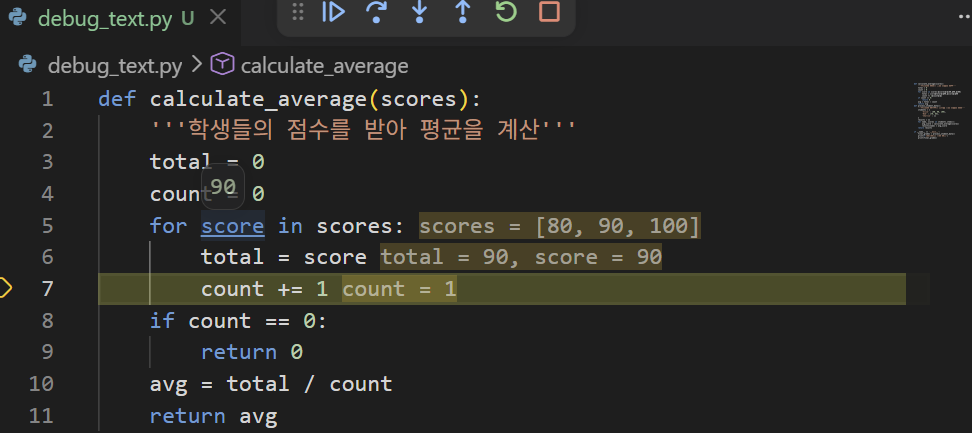
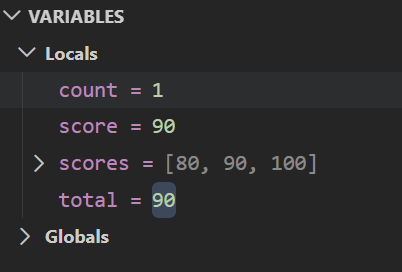

In [ ]:
# 중복 데이터 확인
import pandas as pd
df = pd.read_csv('data/messy_data.csv')
df.duplicated().sum()

In [ ]:
# 중복데이터(내용)
d_index = df.duplicated(keep=False)
df[d_index].sort_values(by=['id'])

In [ ]:
# id는 중복되면 안됨
id_d = df.duplicated(subset=['id'])
df[id_d]

In [ ]:
df.drop_duplicates(keep='last')

In [ ]:
df.drop_duplicates(keep=False)

# [8교시]

# day17_task4_full_pipeline.py
이거 집에서 디버깅 해보기!

## 파이프라인
- 결측치 대치 -> 이상치 처리 -> 중복 데이터 정제

In [ ]:
import pandas as pd
import numpy as np

def run_preprocessing_pipeline(file_path):
    '''file_path : csv 파일명'''
    # 데이터 로드
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except UnicodeEncodeError as e:
        df = pd.read_csv(file_path, encoding = 'cp949')
    # 결측치 처리(대치)
    # age, salary는 중앙값으로 처리
    df['age'].fillna(df['age'].median())
    df['salary'].fillnadf['salary'].fillna(df['salary'].median())
    # score 선형보간 하고 양끝에 남은 NaN은 앞뒤 값으로 채움
    df['score'] = df['score'].interpolate(method='linear')
    df['score'] = df['score'].bfill().ffill()
    # 이상치 처리 capping(경계값으로 이상치를 대치)
    numeric_cols = ['age', 'salary', 'score']
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - IQR * 1.5
        upper = Q3 + IQR * 1.5
        df[col] = df[col].clip(lower=lower, upper=upper)
    # 중복 데이터
    df = df.drop_duplicates(keep = 'first')
    # 종료
    print(f'파이프라인 종료')
    print(f'shape = {df.shape}')

if __name__ == "__main__":
    file_path = 'data/messy_data.csv'
    clean_df = run_preprocessing_pipeline(file_path)
    clean_df.to_csv('data/clean_data.csv', encoding = 'utf-8')
    print('데이터 저장완료')